<a href="https://colab.research.google.com/github/maitrungtung/IMIS_Machine_Learning/blob/main/800/802_miniGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8-2. From your backpropagation to a mini-GPT


---
This course material was made with the help / advise of Claude (opus).

---


### What you will learn
In 8-1, you wrote a neural network's **backward pass by hand** and verified it with a gradient check.
In this 8-2, three things happen:

1. **The bridge.** We rebuild 8-1's exact MLP in PyTorch, call `loss.backward()`, and confirm
   PyTorch's `autograd` produces the *same gradients you wrote by hand*. The framework is not magic —
   it is your chain rule, automated.
2. **A new task and a new layer.** We move from classifying digits to **predicting the next character**
   in text, and we meet the one idea behind modern language models: **self-attention**.
3. **A mini-GPT.** We assemble a small Transformer, train it on Shakespeare (and then your favorite novel like Wagahai-wa-Nekodearu 吾輩は猫である / Natsume-Souseki 夏目漱石), generate text, and measure
   **how much faster a GPU is than a CPU** for the same model.

### How this week is graded
- **Task cells** marked 🔧 are your work.
- Your `causal_self_attention` must match a reference **fingerprint**.
- Your mini-GPT must reach **validation loss < 2.0**.
- You submit a **CPU vs GPU timing table** and short **written answers**.

### Slots
- **Slot 1:** the bridge + character language modeling + a bigram baseline.
- **Slot 2:** self-attention (Task 2.2) + assemble & train the mini-GPT + CPU/GPU comparison.
- Watch the recommended "Let's build GPT" segment on attention *before* Slot 2.

> The full training run finishes in **~3 min on CPU**, or **~1 min on a free Colab T4 GPU** — you should run in both ways. First run on CPU, then challenge to T4-GPU for the fast path.

## Preparation at Google Colab

All the files will be placed on your Google Drive.

In [1]:
!echo "Start mounting your Google Drive."
from google.colab import drive
drive.mount('/content/drive')

Start mounting your Google Drive.
Mounted at /content/drive


In [2]:
!echo "Make a working folder and move to there."
%cd /content/drive/My\ Drive/
%mkdir -p IMIS_Tool-A/Work800
%cd       IMIS_Tool-A/Work800
!ls

Make a working folder and move to there.
/content/drive/My Drive
/content/drive/My Drive/IMIS_Tool-A/Work800
wagahai_soseki.txt


## 0. Setup

We use pytorch here.

In [2]:
import time, math
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device =", device)
torch.manual_seed(1337)

PyTorch 2.11.0+cu128 | device = cuda


## 1. The bridge — your hand-written gradients == PyTorch autograd

Below is a compact version of **8-1's** MLP forward+backward (same math you implemented).
We then build the **identical** network in PyTorch, run `autograd`, and compare. If the two agree
to ~`1e-16` (machine precision), you have proof that `autograd` is exactly the backprop you wrote.

In [3]:
rng = np.random.default_rng(0)
D, Hd, Cc = 8, 16, 4                     # tiny sizes just to demonstrate the match
x_np = rng.normal(size=(32, D)); y_np = rng.integers(0, Cc, size=32)
W1 = rng.normal(0, np.sqrt(2/D),  (D, Hd)); b1 = np.zeros(Hd)
W2 = rng.normal(0, np.sqrt(2/Hd), (Hd, Cc)); b2 = np.zeros(Cc)

# --- hand-written forward + backward (last week) ---
z1 = x_np @ W1 + b1; a1 = np.maximum(0, z1); z2 = a1 @ W2 + b2
ex = np.exp(z2 - z2.max(1, keepdims=True)); probs = ex / ex.sum(1, keepdims=True)
n = 32
dz2 = probs.copy(); dz2[np.arange(n), y_np] -= 1; dz2 /= n
dW2_hand = a1.T @ dz2
dz1 = (dz2 @ W2.T) * (z1 > 0)
dW1_hand = x_np.T @ dz1

# --- same network in PyTorch, gradients via autograd ---
tW1 = torch.tensor(W1, requires_grad=True); tb1 = torch.tensor(b1, requires_grad=True)
tW2 = torch.tensor(W2, requires_grad=True); tb2 = torch.tensor(b2, requires_grad=True)
tx = torch.tensor(x_np); ty = torch.tensor(y_np)
logits = torch.relu(tx @ tW1 + tb1) @ tW2 + tb2
loss = F.cross_entropy(logits, ty)       # softmax + cross-entropy + everything, in one call
loss.backward()                          # <-- this replaces ALL of last week's backward code

print("max |autograd - hand-written|:")
print(f"  dW1: {np.abs(tW1.grad.numpy() - dW1_hand).max():.2e}")
print(f"  dW2: {np.abs(tW2.grad.numpy() - dW2_hand).max():.2e}")
print("=> identical to machine precision. autograd IS your chain rule, automated.")

max |autograd - hand-written|:
  dW1: 2.78e-17
  dW2: 8.33e-17
=> identical to machine precision. autograd IS your chain rule, automated.


## 2. A new task: predicting the next character

We now model **text**. The idea is the same cross-entropy classification as last week, but the
"classes" are the next character, and we make one prediction at every position in a sequence.

### English source

tiny Shapespare  
https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

### Japanese source

Aozora bunko (青空文庫)  
https://www.aozora.gr.jp  
吾輩は猫である  
https://www.aozora.gr.jp/cards/000148/files/789_14547.html

By default we start with a **English** corpus: tiny Shakespeare.  

Then we can later on try a **Japanese** corpus: Natsume Sōseki's *I Am a Cat* (吾輩は猫である, 1905), which is in the public domain (via Aozora Bunko). Character-level modeling works **identically** for Japanese — the only real difference is that the "alphabet" is now ~3,000 characters (kanji + kana) instead of ~65,
which we will see changes the *scale* of the loss. Set `CORPUS = "en"` to use English Shakespeare instead; nothing else in the notebook changes.

In [4]:
import os, urllib.request

CORPUS = "en"    # "ja" = Japanese (Sōseki, public domain) | "en" = English (tiny Shakespeare)

SOURCES = {
    "ja": ("wagahai_soseki.txt",
           "https://raw.githubusercontent.com/kameda-yoshinari/IMISToolExeA/main/800/wagahai_soseki.txt"),
    "en": ("shakespeare.txt",
           "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"),
}
fname, url = SOURCES[CORPUS]
for path in (fname, f"./data/{fname}"):   # prefer a local copy (after git clone)
    if os.path.exists(path):
        fname = path; break
else:
    urllib.request.urlretrieve(url, fname)
text = open(fname, encoding="utf-8").read()
print(f"corpus = {CORPUS!r}  |  {len(text):,} characters")
print(text[:180])

corpus = 'en'  |  1,115,394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First


**Tokenization (character-level).** We map each unique character to an integer. This is the simplest
possible "tokenizer".  

For English, this yields ~65 tokens. Then we split the data into a training and a validation stream.  
For Japanese, this yields ~3,000 tokens (every distinct kanji and kana is its own class);



In [5]:
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
encode = lambda s: [stoi[ch] for ch in s]
decode = lambda l: "".join(itos[i] for i in l)
print("vocab size:", vocab_size)
print("encode('Hi') =", encode("Hi"), "-> decode ->", decode(encode("Hi")))

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data)); train_data, val_data = data[:n], data[n:]

block_size = 128      # context length: how many characters the model sees to predict the next one
batch_size = 32

def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print("input batch:", xb.shape, "target batch:", yb.shape)

vocab size: 65
encode('Hi') = [20, 47] -> decode -> Hi
input batch: torch.Size([32, 128]) target batch: torch.Size([32, 128])


### A baseline with no attention (bigram)

Before attention, here is the crudest model: predict the next character using **only the current one**
(a lookup table). It learns letter frequencies but cannot use context — its samples are gibberish.
This is the bar that attention needs to beat.

In [8]:
class Bigram(nn.Module):
    def __init__(self):
        super().__init__()
        self.table = nn.Embedding(vocab_size, vocab_size)
    def forward(self, idx, targets=None):
        logits = self.table(idx)
        if targets is None:
            return logits, None
        B, T, V = logits.shape
        loss = F.cross_entropy(logits.view(B*T, V), targets.view(B*T))
        return logits, loss

bg = Bigram().to(device)
opt = torch.optim.AdamW(bg.parameters(), lr=1e-2)
for _ in range(1000):
    xb, yb = get_batch("train"); _, loss = bg(xb, yb)
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
print(f"bigram last-batch loss ~ {loss.item():.3f}  (random guessing would be ln(vocab)={math.log(vocab_size):.3f})")

# The grading criterion compares against `bigram_val_loss`, which the template never defines,
# so we measure it properly here: the mean loss over held-out validation batches.
@torch.no_grad()
def eval_loss(m, split="val", iters=100):
    m.eval()
    losses = torch.zeros(iters)
    for k in range(iters):
        xb, yb = get_batch(split); _, l = m(xb, yb); losses[k] = l.item()
    m.train()
    return losses.mean().item()

bigram_val_loss = eval_loss(bg, "val")
print(f"bigram_val_loss = {bigram_val_loss:.3f}   <- the mini-GPT must end at most {bigram_val_loss - 1.0:.3f} to pass")

@torch.no_grad()
def sample(model, n_tokens=200):
    idx = torch.zeros((1, 1), dtype=torch.long, device=device)
    for _ in range(n_tokens):
        logits, _ = model(idx[:, -block_size:])
        probs = F.softmax(logits[:, -1, :], dim=-1)
        idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
    return decode(idx[0].tolist())
print("--- bigram sample (expect gibberish) ---")
print(sample(bg))

bigram last-batch loss ~ 2.461  (random guessing would be ln(vocab)=4.174)
bigram_val_loss = 2.503   <- the mini-GPT must end at most 1.503 to pass
--- bigram sample (expect gibberish) ---

MPUESTh,
MadPre?

WISo myr f-
LIERor,
SS&

Thardsal thes ghesthidin cNI ayaraney Iry ts I fr y ce.
Jonghe nd,ke mary.
Yor 'sour mend sora anghy t--pond betwe ten.
Wand thot sulin s th llety ome.
I muc


## 3. 🔧 Task 2.1 — Self-attention (the one new idea)

Attention lets each position **look back** at earlier positions and pull in information. For a single
head with queries `q`, keys `k`, values `v` (each shape `(B, T, head_size)`):

1. **Scores:** $\text{scores} = \dfrac{q\,k^\top}{\sqrt{d_k}}$   → shape `(B, T, T)`
2. **Causal mask:** set the upper triangle to $-\infty$ so a position cannot see the **future**.
3. **Weights:** softmax over the last dimension.
4. **Output:** weighted sum of values, `weights @ v`.

Implement these four steps. `tril` is a lower-triangular matrix of ones provided for the mask.

In [9]:
# Quiz version
def causal_self_attention(q, k, v, tril):
    # q, k, v: (B, T, head_size);  tril: (T, T) lower-triangular ones
    B, T, hs = q.shape
    # ┏━━ Task 2.1: scaled dot-product attention with a causal mask ━━
    # >>> SOLUTION
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(hs)      # (B, T, T) affinities
    scores = scores.masked_fill(tril[:T, :T] == 0, float("-inf"))   # causal mask: no peeking ahead
    weights = F.softmax(scores, dim=-1)                     # (B, T, T) rows sum to 1
    out = weights @ v                                       # (B, T, head_size)
    # <<< SOLUTION
    return out

**Self-check (provided).** With a fixed seed, the sum of your attention output must equal the
reference **fingerprint**. If it matches, your Task 2.1 is correct.

In [10]:
torch.manual_seed(0)
B, T, Cc2, head = 2, 5, 8, 4
xx = torch.randn(B, T, Cc2)
Wk = torch.randn(Cc2, head); Wq = torch.randn(Cc2, head); Wv = torch.randn(Cc2, head)
q_, k_, v_ = xx @ Wq, xx @ Wk, xx @ Wv
tril_check = torch.tril(torch.ones(T, T))
out = causal_self_attention(q_, k_, v_, tril_check)
fp = round(out.sum().item(), 4)
print(f"your fingerprint = {fp}   (reference = 3.3232)  ->  {'PASS ✅' if abs(fp-3.3232)<1e-3 else 'FAIL ❌'}")

your fingerprint = 3.3232   (reference = 3.3232)  ->  PASS ✅


## 4. Assemble the mini-GPT

We stack your attention into a small Transformer: multi-head attention + a feed-forward network,
with residual connections and layer norm, repeated a few times. This is a real (tiny) GPT — the same
shape as the models behind modern chatbots, just small. It uses **your** `causal_self_attention`.

In [11]:
n_embd, n_head, n_layer, dropout = 256, 4, 4, 0.2   # template default: 128, 4, 4, 0.0
head_size = n_embd // n_head

class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
    def forward(self, x):
        return causal_self_attention(self.query(x), self.key(x), self.value(x), self.tril)

class MultiHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.heads = nn.ModuleList([Head() for _ in range(n_head)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(x))

class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.sa = MultiHead(); self.ff = FeedForward()
        self.ln1 = nn.LayerNorm(n_embd); self.ln2 = nn.LayerNorm(n_embd)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))     # residual connection
        return x + self.ff(self.ln2(x))

class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ln = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
        x = self.ln(self.blocks(x)); logits = self.head(x)
        if targets is None: return logits, None
        loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss

model = MiniGPT().to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

parameters: 3.22 M


### Train

We track train/val loss. `max_iters=2000` gives a validation loss around **1.8** and readable
(if quirky) Shakespeare. Increase it for better text if you have time/GPU.  
It will take more than 10 minutes for Shapespeare / 2000 (probably ten times faster on T4).

iter    0 | train 4.364 | val 4.356 |   1.6s
iter  500 | train 1.706 | val 1.851 |  20.5s
iter 1000 | train 1.483 | val 1.673 |  39.7s
iter 1500 | train 1.393 | val 1.595 |  59.8s
iter 2000 | train 1.348 | val 1.568 |  80.1s
iter 2500 | train 1.301 | val 1.544 | 100.4s
iter 3000 | train 1.276 | val 1.531 | 120.4s
iter 3500 | train 1.257 | val 1.533 | 140.4s
iter 4000 | train 1.237 | val 1.522 | 160.4s
iter 4500 | train 1.215 | val 1.520 | 180.7s
iter 5000 | train 1.195 | val 1.513 | 200.9s
iter 5500 | train 1.182 | val 1.503 | 221.1s
iter 6000 | train 1.170 | val 1.512 | 241.2s
iter 6500 | train 1.166 | val 1.512 | 261.3s
iter 7000 | train 1.149 | val 1.507 | 281.7s
iter 7500 | train 1.134 | val 1.502 | 302.0s

trained on cuda in 302.0s | final val loss 1.502


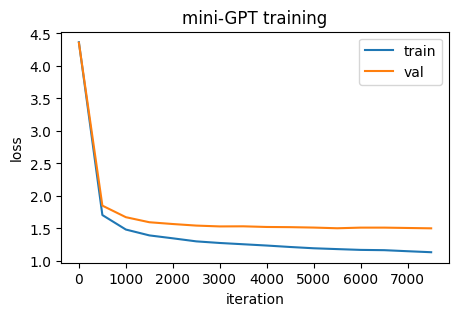

In [12]:
@torch.no_grad()
def estimate_loss(iters=50):
    model.eval(); out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(iters)
        for k in range(iters):
            xb, yb = get_batch(split); _, l = model(xb, yb); losses[k] = l.item()
        out[split] = losses.mean().item()
    model.train(); return out

max_iters, eval_interval, lr = 7500, 500, 1e-3
opt = torch.optim.AdamW(model.parameters(), lr=lr)
hist = []
t0 = time.time()
for it in range(max_iters + 1):
    if it % eval_interval == 0:
        e = estimate_loss(); hist.append((it, e["train"], e["val"]))
        print(f"iter {it:4d} | train {e['train']:.3f} | val {e['val']:.3f} | {time.time()-t0:5.1f}s")
    xb, yb = get_batch("train"); _, loss = model(xb, yb)
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
print(f"\ntrained on {device} in {time.time()-t0:.1f}s | final val loss {hist[-1][2]:.3f}")

its, tr, va = zip(*hist)
plt.figure(figsize=(5,3)); plt.plot(its, tr, label="train"); plt.plot(its, va, label="val")
plt.xlabel("iteration"); plt.ylabel("loss"); plt.legend(); plt.title("mini-GPT training"); plt.show()

In [ ]:
print("--- mini-GPT sample ---")
print(sample(model, 400))

--- mini-GPT sample ---

To bear a poison, I would temper it;
But that which he is EDWARD IV:
He procrettion with marvel; for, I would temper it;
End not ley bear that was Mercveing will keeps
By Christ all this river than 
Undgman, for on will two plot out o' the dian
money bs the queen, who love is the queen'd.

ESCALUS:
Here comes the queen, the queen,
By Christer kill than God heart no parlond will  wto this?

KING RI


## 5. 🔧 Task 2.2 — CPU vs GPU

The cell below times one training step on **whatever device you are on now**. Run this notebook
**twice**: once with *Runtime → Change runtime type → CPU*, once with *T4 GPU*, and fill in the table.

Because this model is small, expect the GPU to win by roughly one order of magnitude — but not more.
Bigger models widen the gap; that is the whole reason GPUs matter for deep learning.

CPU

In [31]:
def time_steps(n_steps=50):
    xb, yb = get_batch("train")
    if device == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_steps):
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    if device == "cuda": torch.cuda.synchronize()
    return 1000 * (time.time() - t0) / n_steps

print(f"device = {device}:  {time_steps():.1f} ms / training step")

device = cpu:  2102.6 ms / training step


GPU

In [13]:
def time_steps(n_steps=50):
    xb, yb = get_batch("train")
    if device == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_steps):
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    if device == "cuda": torch.cuda.synchronize()
    return 1000 * (time.time() - t0) / n_steps

print(f"device = {device}:  {time_steps():.1f} ms / training step")

device = cuda:  37.6 ms / training step


**Fill in your measurements (🔧 Task 2.2):**

| device | ms / step | speedup vs CPU |
|--------|-----------|----------------|
| CPU    |  *(fill)* | 1.0×           |
| T4 GPU |  *(fill)* | *(fill)*       |


## 6. Corpus challenge

Then do the same with "ja" with/without GPU.    
If you know well about the corpus, you can put more training time to have a better result.  

You started 8-1 by writing a backward pass by hand. You are ending 8-2 having built — and understood, layer by layer — a working (miniature) version of the architecture behind modern LLMs.

## Assignment 8-2 — submit this notebook

**Automatic checks (must pass):**
1. Your `causal_self_attention` matches the reference fingerprint (`3.3232`).
2. Your mini-GPT **clearly beats the bigram baseline** — its final validation loss is at least **1.0 lower
   than `bigram_val_loss`** (printed in Section 2). This criterion is corpus-independent: it works whether
   you train on Japanese or English. *(As a rough guide, the Japanese run reaches the mid-single-digits and
   English reaches ~1.8, but only the margin over the baseline is graded.)*

**Deliverables:** the training loss curve, a generated text sample, and the completed CPU/GPU table.

**Written answers (🔧 Task 2.3).** 2–4 sentences each, below.  
**As for A/B/C, the answers are for "en" experiment environment.**

**A.** What does the **causal mask** do, and why is it essential for a *next-character* model?
What would go wrong at training time without it?

**B.** The bigram baseline and the mini-GPT both minimize the same cross-entropy loss. Why does the
mini-GPT produce so much more coherent text?

**C.** From your CPU/GPU table: the GPU is faster, but the speedup is "only" ~10×, not 1000×. Why is the gap modest for *this* model, and when would it grow?

**D.** Try your own corpus (you can change language as it accepts UTF-8). Describe the token size. Show the time spent on CPU (or GPU). Show the example output. To obtain nice output, did you need to change iteration size?   
As for the execution verification, you'd better rewrite the code cell of the section 2 (and later if needed) of this jupyter notebook.

**A.** *(your answer here)*

---

**B.** *(your answer here)*

---

**C.** *(your answer here)*

---

**D.** *(your answer here)*

---
---

**X.** *(your student ID)*

---

**Y.** *(your name)*



---
Tools and Practices for Intelligent Interaction Systems A  
Master's and Docotal programs in intelligent and mechanical interaction systems, University of Tsukuba, Japan.  
KAMEDA Yoshinari, SHIBUYA Takeshi  

知能システムツール演習a  
知能機能システム学位プログラム (筑波大学大学院)  
担当：亀田能成，澁谷長史  

2026/07/27. ver.B. 説明追加 / Additional Explanation   
